In [1]:
import os
for root, dirs, files in os.walk('/kaggle/input/'):
    for file in files:
        print(os.path.join(root, file))

/kaggle/input/datasets/hharikrishnanmr/cleaned-datasets/google_trace_clean (1).csv
/kaggle/input/datasets/hharikrishnanmr/cleaned-datasets/google_trace_labelled (1).csv
/kaggle/input/datasets/hharikrishnanmr/notebooks-1/notebook-1a.ipynb
/kaggle/input/datasets/hharikrishnanmr/datasets-1/part-00000-of-00500 (4).csv
/kaggle/input/datasets/hharikrishnanmr/datasets-1/part-00007-of-00500.csv
/kaggle/input/datasets/hharikrishnanmr/datasets-1/part-00001-of-00500.csv
/kaggle/input/datasets/hharikrishnanmr/datasets-1/part-00009-of-00500.csv
/kaggle/input/datasets/hharikrishnanmr/datasets-1/part-00002-of-00500.csv
/kaggle/input/datasets/hharikrishnanmr/datasets-1/part-00006-of-00500.csv
/kaggle/input/datasets/hharikrishnanmr/datasets-1/part-00005-of-00500.csv
/kaggle/input/datasets/hharikrishnanmr/datasets-1/part-00003-of-00500.csv
/kaggle/input/datasets/hharikrishnanmr/datasets-1/part-00008-of-00500.csv
/kaggle/input/datasets/hharikrishnanmr/datasets-1/part-00004-of-00500.csv


# libraries imported

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:.6f}'.format)

# Loading and reading dataset

In [3]:
CLEAN_PATH    = "/kaggle/input/datasets/hharikrishnanmr/cleaned-datasets/google_trace_clean (1).csv"
LABELLED_PATH = "/kaggle/input/datasets/hharikrishnanmr/cleaned-datasets/google_trace_labelled (1).csv"

df_clean = pd.read_csv(CLEAN_PATH)
df_label = pd.read_csv(LABELLED_PATH)

print("=" * 55)
print("FILES LOADED")
print("=" * 55)
print(f"Clean dataset    : {df_clean.shape[0]:,} rows x {df_clean.shape[1]} cols")
print(f"Labelled dataset : {df_label.shape[0]:,} rows x {df_label.shape[1]} cols")

print(f"\nClean columns :")
for col in df_clean.columns:
    print(f"  {col}")

print(f"\nLabelled columns :")
for col in df_label.columns:
    print(f"  {col}")

FILES LOADED
Clean dataset    : 1,827,856 rows x 13 cols
Labelled dataset : 300,644 rows x 14 cols

Clean columns :
  timestamp
  job_id
  task_index
  machine_id
  event_type
  user
  scheduling_class
  priority
  cpu_requested
  memory_requested
  disk_requested
  different_machine
  event_label

Labelled columns :
  job_id
  task_index
  timestamp
  machine_id
  event_type
  user
  scheduling_class
  priority
  cpu_requested
  memory_requested
  disk_requested
  different_machine
  event_label
  label


In [4]:
RAW_FEATURES = [
    'scheduling_class',   # col 7 - latency sensitivity 0-3
    'priority',           # col 8 - task importance 0-11
    'cpu_requested',      # col 9 - normalised CPU request
    'memory_requested',   # col 10 - normalised memory request
    'disk_requested',     # col 11 - normalised disk request
    'different_machine'   # col 12 - placement constraint flag
]

print("=" * 55)
print("RAW FEATURES — SUMMARY STATISTICS")
print("=" * 55)
print(df_label[RAW_FEATURES].describe().round(4))

print("\n" + "=" * 55)
print("NULL CHECK ON RAW FEATURES")
print("=" * 55)
print(df_label[RAW_FEATURES].isnull().sum())

print("\n" + "=" * 55)
print("RAW FEATURES vs LABEL")
print("=" * 55)
# Mean value of each raw feature per class
print(df_label.groupby('label')[RAW_FEATURES].mean().round(4))

RAW FEATURES — SUMMARY STATISTICS
       scheduling_class      priority  cpu_requested  memory_requested  \
count     300644.000000 300644.000000  300644.000000     300644.000000   
mean           0.200500      1.739300       0.036100          0.028300   
std            0.486500      1.267300       0.031400          0.029200   
min            0.000000      0.000000       0.000000          0.000000   
25%            0.000000      2.000000       0.012500          0.009300   
50%            0.000000      2.000000       0.025000          0.025400   
75%            0.000000      2.000000       0.062500          0.033400   
max            3.000000     10.000000       0.500000          0.190900   

       disk_requested  different_machine  
count   300644.000000      300644.000000  
mean         0.000300           0.251700  
std          0.001000           0.434000  
min          0.000000           0.000000  
25%          0.000000           0.000000  
50%          0.000200           0.000000 

# SCHEDULING DELAY

Time between task SUBMITTED and SCHEDULED which is 
timestamp(SCHEDULE) - timestamp(SUBMIT)

Negative delays removed : 0
SCHEDULING DELAY STATISTICS (seconds)
count   443257.000000
mean        66.880000
std        786.770000
min          0.000000
25%          0.000000
50%          1.680000
75%          3.580000
max      47901.990000
Name: scheduling_delay_sec, dtype: float64

SCHEDULING DELAY vs LABEL
           mean   median        std
label                              
0     12.270000 2.320000  36.650000
1     75.460000 2.290000 811.940000


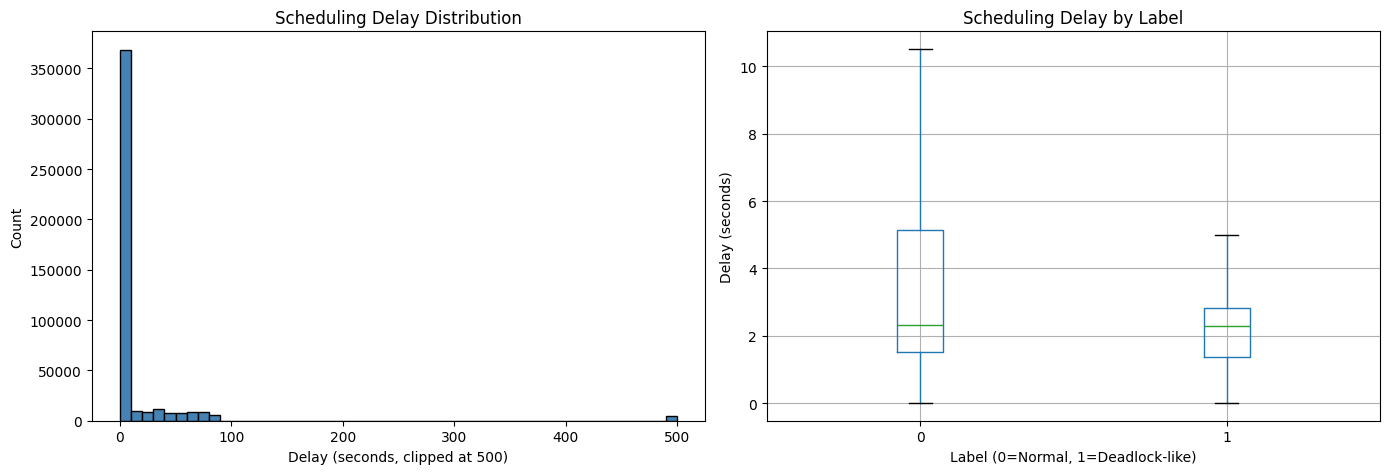


Tasks with scheduling delay data : 443,257
Novel Feature 1 — scheduling_delay_sec created 


In [5]:
submit_times = (
    df_clean[df_clean['event_type'] == 0]
    .groupby(['job_id', 'task_index'])['timestamp']
    .min()
    .reset_index()
    .rename(columns={'timestamp': 'submit_time'})
)

schedule_times = (
    df_clean[df_clean['event_type'] == 1]
    .groupby(['job_id', 'task_index'])['timestamp']
    .min()
    .reset_index()
    .rename(columns={'timestamp': 'schedule_time'})
)

delay_df = submit_times.merge(
    schedule_times,
    on=['job_id', 'task_index'],
    how='inner'
)

delay_df['scheduling_delay_sec'] = (
    (delay_df['schedule_time'] - delay_df['submit_time']) 
    / 1_000_000
)

before = len(delay_df)
delay_df = delay_df[delay_df['scheduling_delay_sec'] >= 0]
print(f"Negative delays removed : {before - len(delay_df):,}")

print("=" * 55)
print("SCHEDULING DELAY STATISTICS (seconds)")
print("=" * 55)
print(delay_df['scheduling_delay_sec'].describe().round(2))

# Comparing delay between label 0 and label 1
delay_with_label = delay_df.merge(
    df_label[['job_id', 'task_index', 'label']],
    on=['job_id', 'task_index'],
    how='inner'
)

print("\n" + "=" * 55)
print("SCHEDULING DELAY vs LABEL")
print("=" * 55)
print(delay_with_label.groupby('label')['scheduling_delay_sec']
      .agg(['mean', 'median', 'std']).round(2))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Novel Feature 1 — Scheduling Delay', fontweight='bold')

axes[0].hist(
    delay_df['scheduling_delay_sec'].clip(upper=500),
    bins=50, color='steelblue', edgecolor='black'
)
axes[0].set_title('Scheduling Delay Distribution')
axes[0].set_xlabel('Delay (seconds, clipped at 500)')
axes[0].set_ylabel('Count')

delay_with_label.boxplot(
    column='scheduling_delay_sec',
    by='label',
    ax=axes[1],
    showfliers=False
)
axes[1].set_title('Scheduling Delay by Label')
axes[1].set_xlabel('Label (0=Normal, 1=Deadlock-like)')
axes[1].set_ylabel('Delay (seconds)')
plt.suptitle('')

plt.tight_layout()
plt.savefig('scheduling_delay.png', dpi=150)
plt.show()

print(f"\nTasks with scheduling delay data : {len(delay_df):,}")
print("Novel Feature 1 — scheduling_delay_sec created ")

# EXECUTION DURATION

Time between SCHEDULE and final terminal event which is timestamp(final event) - timestamp(SCHEDULE)

Negative durations removed : 0
EXECUTION DURATION STATISTICS (seconds)
count   291774.000000
mean      2575.470000
std       5132.930000
min          0.840000
25%        181.180000
50%        551.020000
75%       2505.370000
max      50247.620000
Name: execution_duration_sec, dtype: float64

EXECUTION DURATION vs LABEL
             mean     median         std
label                                   
0     1948.880000 555.950000 3665.250000
1     4840.380000 539.110000 8153.160000


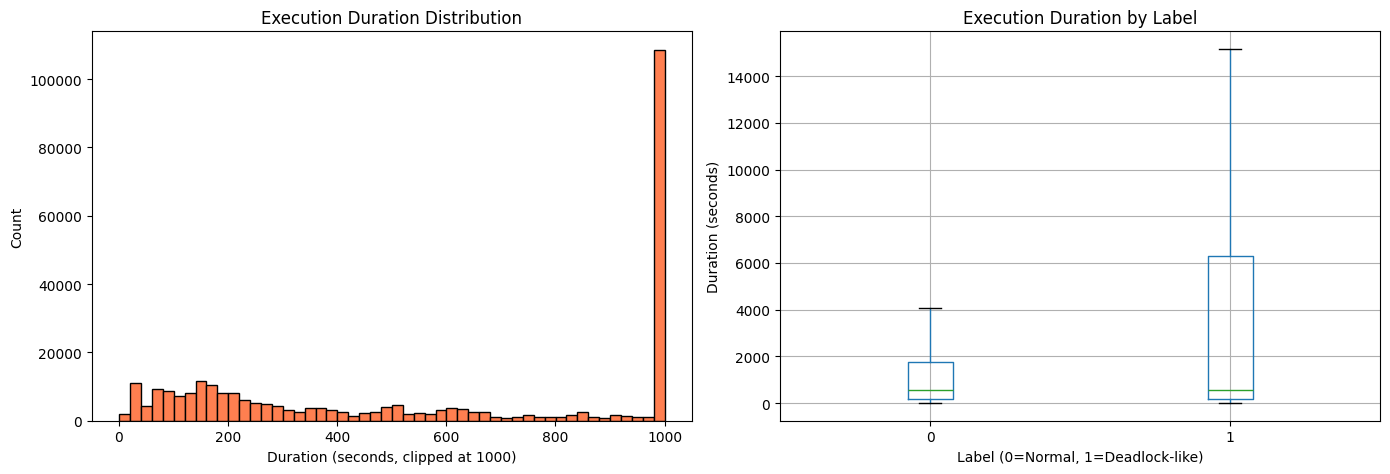


Tasks with execution duration data : 291,774
Novel Feature 2 — execution_duration_sec created 


In [6]:
# SCHEDULE timestamp per task
sched_times = (
    df_clean[df_clean['event_type'] == 1]
    .groupby(['job_id', 'task_index'])['timestamp']
    .min()
    .reset_index()
    .rename(columns={'timestamp': 'sched_time'})
)

final_times = (
    df_label[['job_id', 'task_index', 'timestamp', 'label']]
    .rename(columns={'timestamp': 'final_time'})
)

duration_df = sched_times.merge(
    final_times,
    on=['job_id', 'task_index'],
    how='inner'
)

duration_df['execution_duration_sec'] = (
    (duration_df['final_time'] - duration_df['sched_time'])
    / 1_000_000
)

# Removing negative durations
before = len(duration_df)
duration_df = duration_df[duration_df['execution_duration_sec'] >= 0]
print(f"Negative durations removed : {before - len(duration_df):,}")

print("=" * 55)
print("EXECUTION DURATION STATISTICS (seconds)")
print("=" * 55)
print(duration_df['execution_duration_sec'].describe().round(2))

print("\n" + "=" * 55)
print("EXECUTION DURATION vs LABEL")
print("=" * 55)
print(duration_df.groupby('label')['execution_duration_sec']
      .agg(['mean', 'median', 'std']).round(2))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Novel Feature 2 — Execution Duration', fontweight='bold')

axes[0].hist(
    duration_df['execution_duration_sec'].clip(upper=1000),
    bins=50, color='coral', edgecolor='black'
)
axes[0].set_title('Execution Duration Distribution')
axes[0].set_xlabel('Duration (seconds, clipped at 1000)')
axes[0].set_ylabel('Count')

duration_df.boxplot(
    column='execution_duration_sec',
    by='label',
    ax=axes[1],
    showfliers=False
)
axes[1].set_title('Execution Duration by Label')
axes[1].set_xlabel('Label (0=Normal, 1=Deadlock-like)')
axes[1].set_ylabel('Duration (seconds)')
plt.suptitle('')

plt.tight_layout()
plt.savefig('execution_duration.png', dpi=150)
plt.show()

print(f"\nTasks with execution duration data : {len(duration_df):,}")
print("Novel Feature 2 — execution_duration_sec created ")

# MACHINE FAILURE RATE 

Proportion of failure events per machine which is count(FAIL+KILL+EVICT on machine) /
              count(all events on machine)

MACHINE FAILURE RATE STATISTICS
count   12509.000000
mean        0.182800
std         0.063900
min         0.000000
25%         0.150000
50%         0.186600
75%         0.222200
max         0.432100
Name: machine_failure_rate, dtype: float64

MACHINE FAILURE RATE BREAKDOWN
Total machines tracked          : 12,509
Machines with 0% failure rate   : 369
Machines with >10% failure rate : 11,401
Machines with >50% failure rate : 0

MACHINE FAILURE RATE vs LABEL
          mean   median      std
label                           
0     0.188300 0.187500 0.050100
1     0.205300 0.203500 0.052200


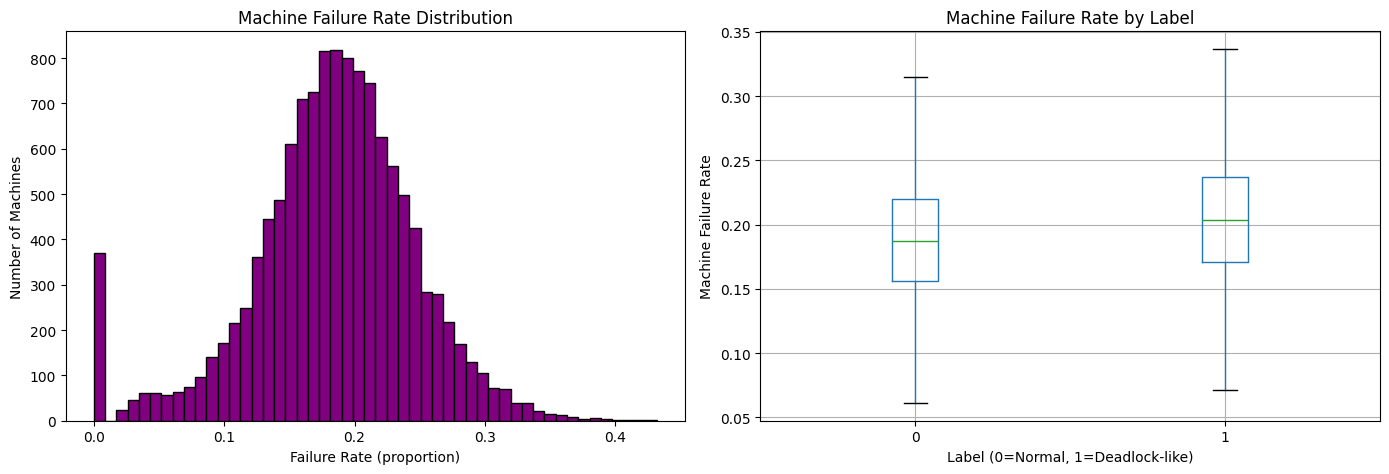


Machine failure rate created 
Novel Feature 3 — machine_failure_rate created 


In [7]:
machine_df = df_clean[df_clean['machine_id'] != -1].copy()

total_per_machine = (
    machine_df
    .groupby('machine_id')['event_type']
    .count()
    .reset_index()
    .rename(columns={'event_type': 'total_events'})
)

# Counting failure events per machine
# FAIL=3, KILL=5, EVICT=2
failure_events = machine_df[machine_df['event_type'].isin([2, 3, 5])]
fail_per_machine = (
    failure_events
    .groupby('machine_id')['event_type']
    .count()
    .reset_index()
    .rename(columns={'event_type': 'failure_events'})
)

machine_stats = total_per_machine.merge(
    fail_per_machine,
    on='machine_id',
    how='left'
)
machine_stats['failure_events'] = machine_stats['failure_events'].fillna(0)
machine_stats['machine_failure_rate'] = (
    machine_stats['failure_events'] / machine_stats['total_events']
)

print("=" * 55)
print("MACHINE FAILURE RATE STATISTICS")
print("=" * 55)
print(machine_stats['machine_failure_rate'].describe().round(4))

print("\n" + "=" * 55)
print("MACHINE FAILURE RATE BREAKDOWN")
print("=" * 55)
print(f"Total machines tracked          : {len(machine_stats):,}")
print(f"Machines with 0% failure rate   : "
      f"{(machine_stats['machine_failure_rate']==0).sum():,}")
print(f"Machines with >10% failure rate : "
      f"{(machine_stats['machine_failure_rate']>0.1).sum():,}")
print(f"Machines with >50% failure rate : "
      f"{(machine_stats['machine_failure_rate']>0.5).sum():,}")

# Mapping machine failure rate to labelled tasks
label_with_machine = df_label[
    ['job_id', 'task_index', 'machine_id', 'label']
].merge(
    machine_stats[['machine_id', 'machine_failure_rate']],
    on='machine_id',
    how='left'
)

print("\n" + "=" * 55)
print("MACHINE FAILURE RATE vs LABEL")
print("=" * 55)
print(label_with_machine.groupby('label')['machine_failure_rate']
      .agg(['mean', 'median', 'std']).round(4))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Novel Feature 3 — Machine Failure Rate', fontweight='bold')

axes[0].hist(
    machine_stats['machine_failure_rate'],
    bins=50, color='purple', edgecolor='black'
)
axes[0].set_title('Machine Failure Rate Distribution')
axes[0].set_xlabel('Failure Rate (proportion)')
axes[0].set_ylabel('Number of Machines')

label_with_machine.boxplot(
    column='machine_failure_rate',
    by='label',
    ax=axes[1],
    showfliers=False
)
axes[1].set_title('Machine Failure Rate by Label')
axes[1].set_xlabel('Label (0=Normal, 1=Deadlock-like)')
axes[1].set_ylabel('Machine Failure Rate')
plt.suptitle('')

plt.tight_layout()
plt.savefig('machine_failure_rate.png', dpi=150)
plt.show()

print(f"\nMachine failure rate created ")
print("Novel Feature 3 — machine_failure_rate created ")

# CONCURRENCY DENSITY

Number of tasks scheduled on the same machine within the same 60-second time window.
 FORMULA    : count(SCHEDULE events on machine_id
              in same 60s window as this task)

CONCURRENCY DENSITY STATISTICS
count   442019.000000
mean         1.450000
std          1.760000
min          1.000000
25%          1.000000
50%          1.000000
75%          1.000000
max         29.000000
Name: concurrency_density, dtype: float64

CONCURRENCY DENSITY vs LABEL
          mean   median      std
label                           
0     1.650000 1.000000 2.210000
1     2.120000 1.000000 3.060000


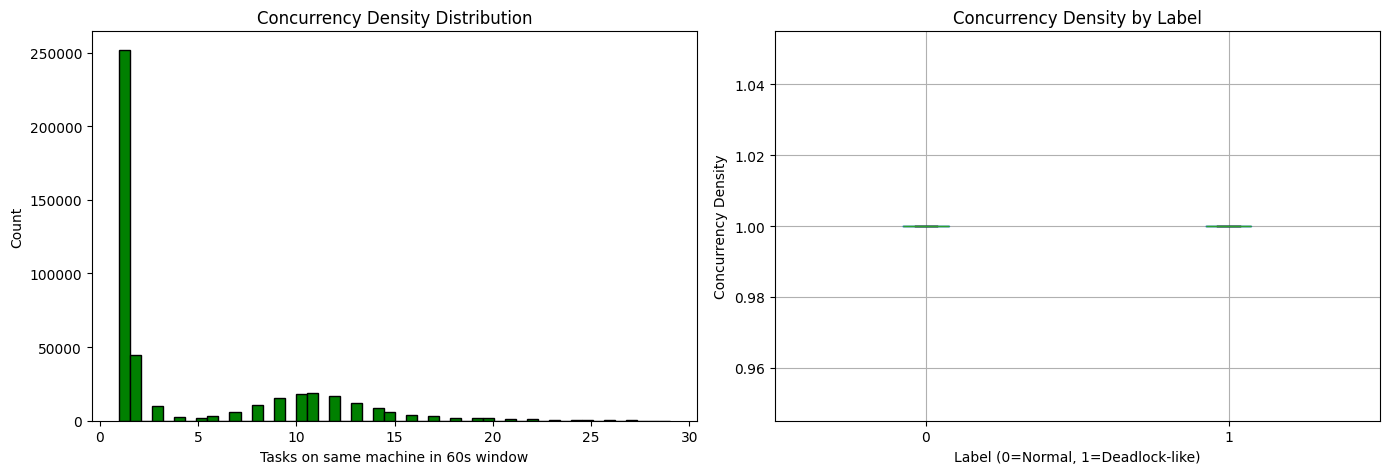


Tasks with concurrency data : 443,257
Novel Feature 4 — concurrency_density created 


In [8]:
# scheduling events with real machine assignments
scheduled = df_clean[
    (df_clean['event_type'] == 1) &
    (df_clean['machine_id'] != -1)
].copy()

# Converting timestamp to seconds and assign time window
scheduled['timestamp_sec'] = scheduled['timestamp'] / 1_000_000
scheduled['time_window'] = (scheduled['timestamp_sec'] // 60).astype(int)

# Counting tasks per machine per time window
concurrency = (
    scheduled
    .groupby(['machine_id', 'time_window'])
    .size()
    .reset_index()
    .rename(columns={0: 'concurrency_density'})
)

print("=" * 55)
print("CONCURRENCY DENSITY STATISTICS")
print("=" * 55)
print(concurrency['concurrency_density'].describe().round(2))

# Mapping back to each task
scheduled = scheduled.merge(
    concurrency,
    on=['machine_id', 'time_window'],
    how='left'
)

# Takingn first concurrency value per task
concurrency_per_task = (
    scheduled
    .groupby(['job_id', 'task_index'])['concurrency_density']
    .first()
    .reset_index()
)

# Comparing between label 0 and label 1
concurrency_with_label = concurrency_per_task.merge(
    df_label[['job_id', 'task_index', 'label']],
    on=['job_id', 'task_index'],
    how='inner'
)

print("\n" + "=" * 55)
print("CONCURRENCY DENSITY vs LABEL")
print("=" * 55)
print(concurrency_with_label.groupby('label')['concurrency_density']
      .agg(['mean', 'median', 'std']).round(2))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Novel Feature 4 — Concurrency Density', fontweight='bold')

axes[0].hist(
    concurrency_per_task['concurrency_density'].clip(upper=100),
    bins=50, color='green', edgecolor='black'
)
axes[0].set_title('Concurrency Density Distribution')
axes[0].set_xlabel('Tasks on same machine in 60s window')
axes[0].set_ylabel('Count')

concurrency_with_label.boxplot(
    column='concurrency_density',
    by='label',
    ax=axes[1],
    showfliers=False
)
axes[1].set_title('Concurrency Density by Label')
axes[1].set_xlabel('Label (0=Normal, 1=Deadlock-like)')
axes[1].set_ylabel('Concurrency Density')
plt.suptitle('')

plt.tight_layout()
plt.savefig('concurrency_density.png', dpi=150)
plt.show()

print(f"\nTasks with concurrency data : {len(concurrency_per_task):,}")
print("Novel Feature 4 — concurrency_density created ")

Didnt got expected results so retrying it with 300s (5 min) to capture more concurrency

CONCURRENCY DENSITY (300s window) vs LABEL
          mean   median      std
label                           
0     1.960000 1.000000 2.300000
1     2.450000 1.000000 3.100000


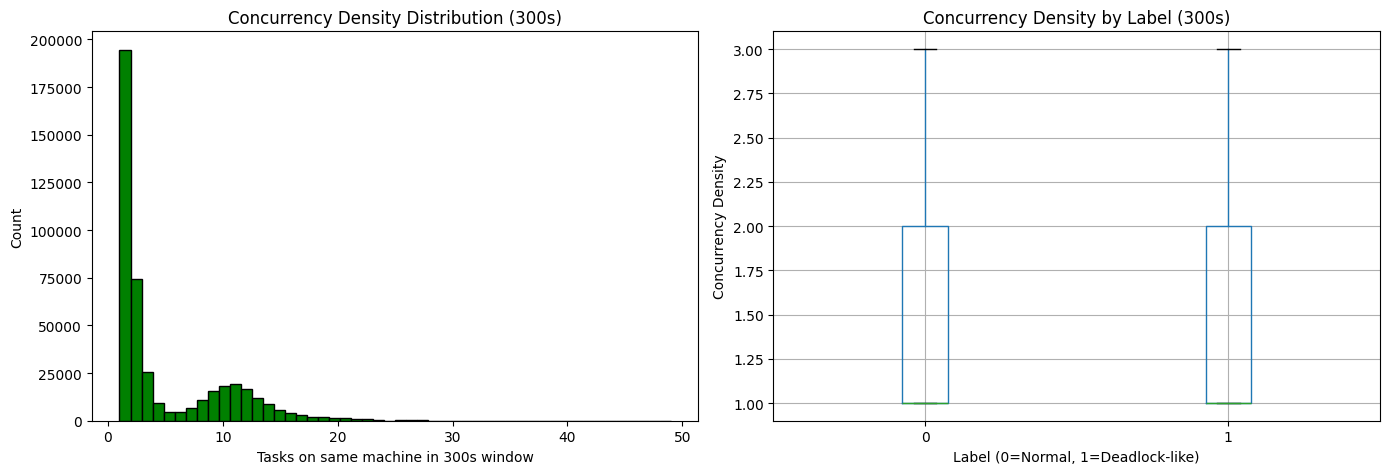

Novel Feature 4 revised — concurrency_density created


In [9]:
scheduled['time_window_300'] = (scheduled['timestamp_sec'] // 300).astype(int)

concurrency_300 = (
    scheduled
    .groupby(['machine_id', 'time_window_300'])
    .size()
    .reset_index()
    .rename(columns={0: 'concurrency_density_300'})
)

scheduled = scheduled.merge(
    concurrency_300,
    on=['machine_id', 'time_window_300'],
    how='left'
)

concurrency_per_task = (
    scheduled
    .groupby(['job_id', 'task_index'])['concurrency_density_300']
    .first()
    .reset_index()
    .rename(columns={'concurrency_density_300': 'concurrency_density'})
)

concurrency_with_label = concurrency_per_task.merge(
    df_label[['job_id', 'task_index', 'label']],
    on=['job_id', 'task_index'],
    how='inner'
)

print("=" * 55)
print("CONCURRENCY DENSITY (300s window) vs LABEL")
print("=" * 55)
print(concurrency_with_label.groupby('label')['concurrency_density']
      .agg(['mean', 'median', 'std']).round(2))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Novel Feature 4 — Concurrency Density (300s window)', 
             fontweight='bold')

axes[0].hist(
    concurrency_per_task['concurrency_density'].clip(upper=150),
    bins=50, color='green', edgecolor='black'
)
axes[0].set_title('Concurrency Density Distribution (300s)')
axes[0].set_xlabel('Tasks on same machine in 300s window')
axes[0].set_ylabel('Count')

concurrency_with_label.boxplot(
    column='concurrency_density',
    by='label',
    ax=axes[1],
    showfliers=False
)
axes[1].set_title('Concurrency Density by Label (300s)')
axes[1].set_xlabel('Label (0=Normal, 1=Deadlock-like)')
axes[1].set_ylabel('Concurrency Density')
plt.suptitle('')

plt.tight_layout()
plt.savefig('concurrency_density_300s.png', dpi=150)
plt.show()

print("Novel Feature 4 revised — concurrency_density created")

# RESOURCE OVERCOMMIT RATIO

How much more CPU this task requested compared to the average on its machine

 FORMULA    : task cpu_requested / mean(cpu_requested on machine)


  RESOURCE OVERCOMMIT RATIO STATISTICS
count   441194.000000
mean         1.097600
std          1.071300
min          0.004000
25%          0.359200
50%          0.796300
75%          1.543600
max         15.755700
Name: resource_overcommit_ratio, dtype: float64

  RESOURCE OVERCOMMIT RATIO vs LABEL
          mean   median      std
label                           
0     0.914000 0.728900 0.739300
1     0.970100 0.793000 0.766500


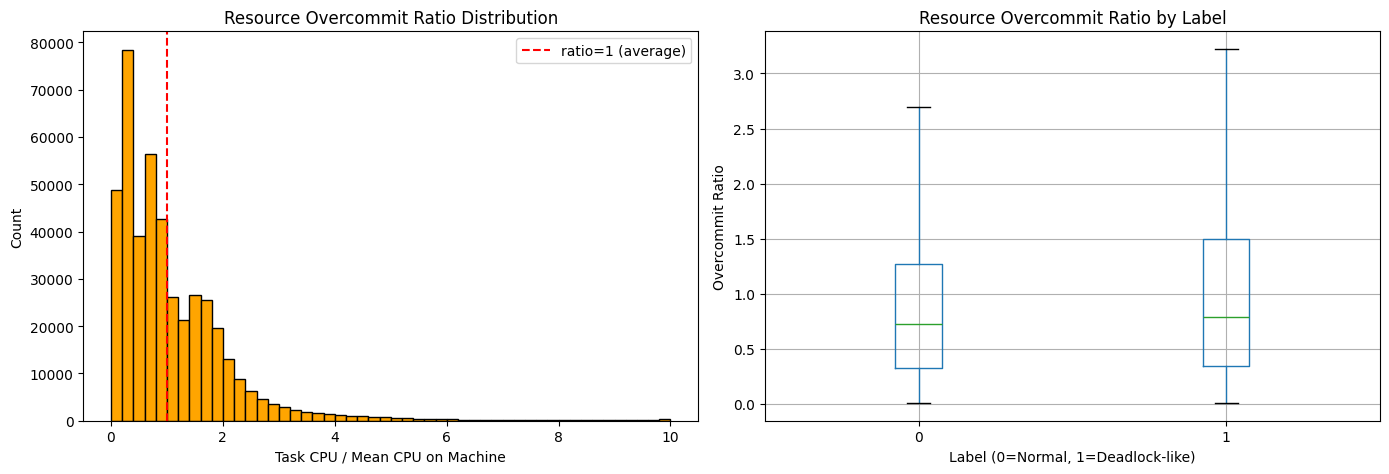


Tasks with overcommit data : 441,194
Novel Feature 5 — resource_overcommit_ratio created 


In [10]:
# Getting schedule events with resources and real machines
sched_resources = df_clean[
    (df_clean['event_type'] == 1) &
    (df_clean['machine_id'] != -1) &
    (df_clean['cpu_requested'] > 0)
].copy()

mean_cpu_per_machine = (
    sched_resources
    .groupby('machine_id')['cpu_requested']
    .mean()
    .reset_index()
    .rename(columns={'cpu_requested': 'mean_cpu_on_machine'})
)

# Merging back to get machine average alongside task request
sched_resources = sched_resources.merge(
    mean_cpu_per_machine,
    on='machine_id',
    how='left'
)

# Calculate ratio
# ratio > 1 means task requests more than machine average
# ratio < 1 means task requests less than machine average
sched_resources['resource_overcommit_ratio'] = (
    sched_resources['cpu_requested'] /
    sched_resources['mean_cpu_on_machine']
)

# One value per task
overcommit_per_task = (
    sched_resources
    .groupby(['job_id', 'task_index'])['resource_overcommit_ratio']
    .first()
    .reset_index()
)

print("=" * 55)
print("  RESOURCE OVERCOMMIT RATIO STATISTICS")
print("=" * 55)
print(overcommit_per_task['resource_overcommit_ratio'].describe().round(4))

# Compare between classes
overcommit_with_label = overcommit_per_task.merge(
    df_label[['job_id', 'task_index', 'label']],
    on=['job_id', 'task_index'],
    how='inner'
)

print("\n" + "=" * 55)
print("  RESOURCE OVERCOMMIT RATIO vs LABEL")
print("=" * 55)
print(overcommit_with_label.groupby('label')['resource_overcommit_ratio']
      .agg(['mean', 'median', 'std']).round(4))

# Step 7 — Visualise
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Novel Feature 5 — Resource Over-commitment Ratio',
             fontweight='bold')

axes[0].hist(
    overcommit_per_task['resource_overcommit_ratio'].clip(upper=10),
    bins=50, color='orange', edgecolor='black'
)
axes[0].set_title('Resource Overcommit Ratio Distribution')
axes[0].set_xlabel('Task CPU / Mean CPU on Machine')
axes[0].set_ylabel('Count')
axes[0].axvline(x=1, color='red', linestyle='--', label='ratio=1 (average)')
axes[0].legend()

overcommit_with_label.boxplot(
    column='resource_overcommit_ratio',
    by='label',
    ax=axes[1],
    showfliers=False
)
axes[1].set_title('Resource Overcommit Ratio by Label')
axes[1].set_xlabel('Label (0=Normal, 1=Deadlock-like)')
axes[1].set_ylabel('Overcommit Ratio')
plt.suptitle('')

plt.tight_layout()
plt.savefig('resource_overcommit.png', dpi=150)
plt.show()

print(f"\nTasks with overcommit data : {len(overcommit_per_task):,}")
print("Novel Feature 5 — resource_overcommit_ratio created ")

# PRIORITY INVERSION FLAG

Flag=1 if a lower priority task was scheduled while higher priority tasks were waiting

FORMULA    : task priority < max(priority of SUBMIT events in same time window)

 MAX WAITING PRIORITY DISTRIBUTION
count   837.000000
mean      9.280000
std       0.520000
min       8.000000
25%       9.000000
50%       9.000000
75%      10.000000
max      11.000000
Name: max_waiting_priority, dtype: float64

  PRIORITY INVERSION FLAG DISTRIBUTION
No inversion (0) : 8,703
Inversion    (1) : 434,554
Inversion rate   : 98.0%

  PRIORITY INVERSION FLAG vs LABEL
          mean     sum
label                 
0     0.994900  227387
1     0.992100   62728

Cross tabulation:
priority_inversion_flag     0       1     All
label                                        
0                        1159  227387  228546
1                         500   62728   63228
All                      1659  290115  291774


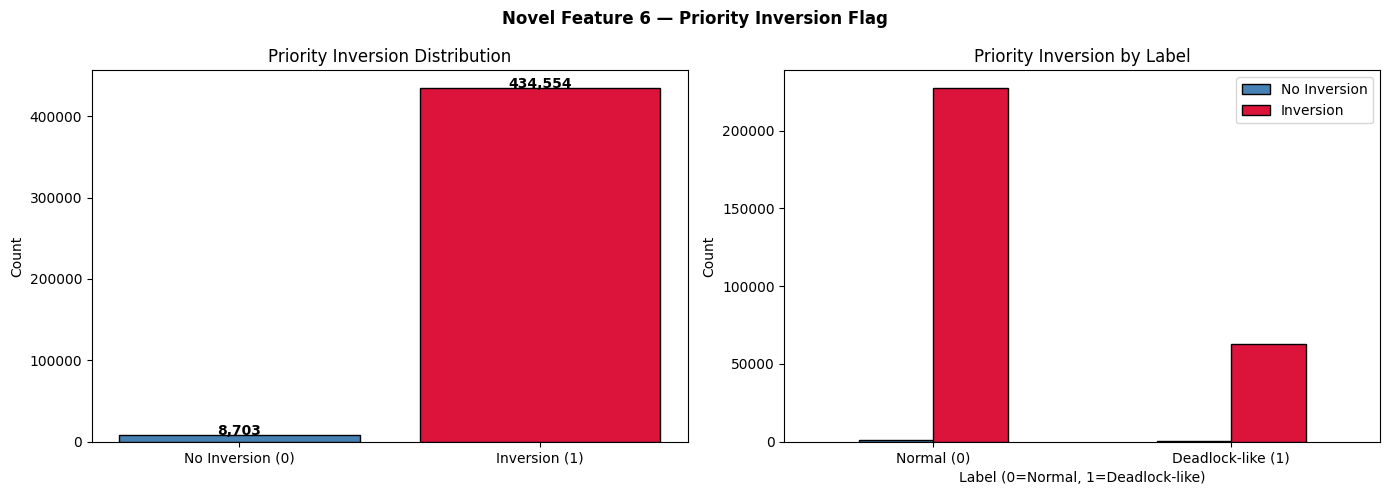

Novel Feature 6 — priority_inversion_flag created 


In [11]:
# Getting waiting tasks - SUBMIT state with priority
waiting = df_clean[df_clean['event_type'] == 0][
    ['job_id', 'task_index', 'timestamp', 'priority']
].copy()
waiting['timestamp_sec'] = waiting['timestamp'] / 1_000_000
waiting['time_window'] = (waiting['timestamp_sec'] // 60).astype(int)

# Getting max priority of waiting tasks per time window
max_waiting_priority = (
    waiting
    .groupby('time_window')['priority']
    .max()
    .reset_index()
    .rename(columns={'priority': 'max_waiting_priority'})
)

print("=" * 55)
print(" MAX WAITING PRIORITY DISTRIBUTION")
print("=" * 55)
print(max_waiting_priority['max_waiting_priority'].describe().round(2))

# Getting scheduled tasks with priority and time window
sched_prio = df_clean[df_clean['event_type'] == 1][
    ['job_id', 'task_index', 'timestamp', 'priority']
].copy()
sched_prio['timestamp_sec'] = sched_prio['timestamp'] / 1_000_000
sched_prio['time_window'] = (sched_prio['timestamp_sec'] // 60).astype(int)

# Merging to compare scheduled priority vs max waiting
sched_prio = sched_prio.merge(
    max_waiting_priority,
    on='time_window',
    how='left'
)

# Flag inversion
# 1 = this scheduled task has lower priority than someone waiting
sched_prio['priority_inversion_flag'] = (
    sched_prio['priority'] < sched_prio['max_waiting_priority']
).astype(int)

# One value per task
priority_inv_per_task = (
    sched_prio
    .groupby(['job_id', 'task_index'])['priority_inversion_flag']
    .first()
    .reset_index()
)

print("\n" + "=" * 55)
print("  PRIORITY INVERSION FLAG DISTRIBUTION")
print("=" * 55)
counts = priority_inv_per_task['priority_inversion_flag'].value_counts()
print(f"No inversion (0) : {counts.get(0, 0):,}")
print(f"Inversion    (1) : {counts.get(1, 0):,}")
print(f"Inversion rate   : "
      f"{counts.get(1,0)/len(priority_inv_per_task)*100:.1f}%")

# Comparing between classes
inv_with_label = priority_inv_per_task.merge(
    df_label[['job_id', 'task_index', 'label']],
    on=['job_id', 'task_index'],
    how='inner'
)

print("\n" + "=" * 55)
print("  PRIORITY INVERSION FLAG vs LABEL")
print("=" * 55)
print(inv_with_label.groupby('label')['priority_inversion_flag']
      .agg(['mean', 'sum']).round(4))
print("\nCross tabulation:")
print(pd.crosstab(inv_with_label['label'],
                  inv_with_label['priority_inversion_flag'],
                  margins=True))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Novel Feature 6 — Priority Inversion Flag', fontweight='bold')

axes[0].bar(['No Inversion (0)', 'Inversion (1)'],
            [counts.get(0,0), counts.get(1,0)],
            color=['steelblue', 'crimson'], edgecolor='black')
axes[0].set_title('Priority Inversion Distribution')
axes[0].set_ylabel('Count')
for i, v in enumerate([counts.get(0,0), counts.get(1,0)]):
    axes[0].text(i, v + 100, f'{v:,}', ha='center', fontweight='bold')

inv_grouped = inv_with_label.groupby(
    ['label', 'priority_inversion_flag']
).size().unstack(fill_value=0)
inv_grouped.plot(kind='bar', ax=axes[1],
                 color=['steelblue', 'crimson'],
                 edgecolor='black')
axes[1].set_title('Priority Inversion by Label')
axes[1].set_xlabel('Label (0=Normal, 1=Deadlock-like)')
axes[1].set_ylabel('Count')
axes[1].set_xticklabels(['Normal (0)', 'Deadlock-like (1)'], rotation=0)
axes[1].legend(['No Inversion', 'Inversion'])

plt.tight_layout()
plt.savefig('priority_inversion.png', dpi=150)
plt.show()

print("Novel Feature 6 — priority_inversion_flag created ")

# PRIORITY GAP 

A larger gap = more severe inversion = more contention risk,
 FORMULA : max_waiting_priority - scheduled_task_priority
 Positive value = inversion exists, bigger = more severe
 Zero or negative = no inversion


  PRIORITY GAP STATISTICS
count   443257.000000
mean         7.260000
std          2.650000
min          0.000000
25%          7.000000
50%          7.000000
75%          9.000000
max         11.000000
Name: priority_gap, dtype: float64

  PRIORITY GAP vs LABEL
          mean   median      std
label                           
0     7.565800 7.000000 1.233200
1     7.892500 8.000000 2.020600


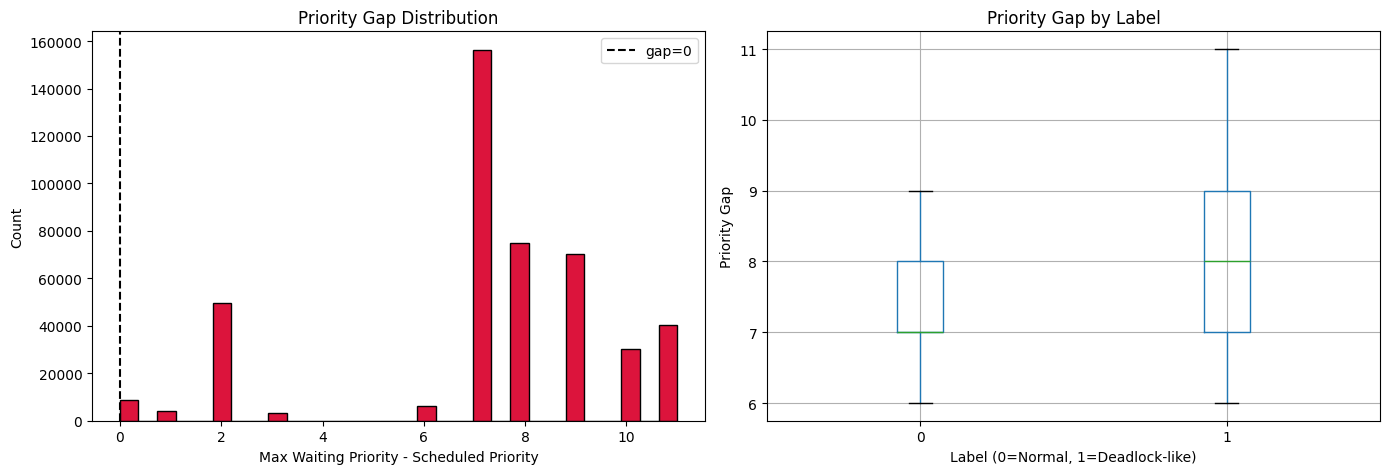

Novel Feature 6 revised — priority_gap created 


In [12]:
sched_prio['priority_gap'] = (
    sched_prio['max_waiting_priority'] - sched_prio['priority']
)

# One value per task
priority_gap_per_task = (
    sched_prio
    .groupby(['job_id', 'task_index'])['priority_gap']
    .first()
    .reset_index()
)

print("=" * 55)
print("  PRIORITY GAP STATISTICS")
print("=" * 55)
print(priority_gap_per_task['priority_gap'].describe().round(2))

gap_with_label = priority_gap_per_task.merge(
    df_label[['job_id', 'task_index', 'label']],
    on=['job_id', 'task_index'],
    how='inner'
)

print("\n" + "=" * 55)
print("  PRIORITY GAP vs LABEL")
print("=" * 55)
print(gap_with_label.groupby('label')['priority_gap']
      .agg(['mean', 'median', 'std']).round(4))

# Visualisation
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Novel Feature 6 — Priority Gap (revised)', fontweight='bold')

axes[0].hist(
    priority_gap_per_task['priority_gap'],
    bins=30, color='crimson', edgecolor='black'
)
axes[0].set_title('Priority Gap Distribution')
axes[0].set_xlabel('Max Waiting Priority - Scheduled Priority')
axes[0].set_ylabel('Count')
axes[0].axvline(x=0, color='black', linestyle='--', label='gap=0')
axes[0].legend()

gap_with_label.boxplot(
    column='priority_gap',
    by='label',
    ax=axes[1],
    showfliers=False
)
axes[1].set_title('Priority Gap by Label')
axes[1].set_xlabel('Label (0=Normal, 1=Deadlock-like)')
axes[1].set_ylabel('Priority Gap')
plt.suptitle('')

plt.tight_layout()
plt.savefig('priority_gap.png', dpi=150)
plt.show()

priority_inv_per_task = priority_gap_per_task.rename(
    columns={'priority_gap': 'priority_inversion_flag'}
)

print("Novel Feature 6 revised — priority_gap created ")

# MERGING ALL FEATURES INTO FEATURE MATRIX 

Combining all raw and engineered features with labelled dataset

# Raw features    (6) : 
                       scheduling_class,
                       priority,
                       cpu_requested,
                       memory_requested,
                       disk_requested,
                       different_machine

# Novel features  (6) : 
                       scheduling_delay_sec,
                       execution_duration_sec,
                       machine_failure_rate,
                       concurrency_density,
                       resource_overcommit_ratio,
                       priority_inversion_flag (priority_gap)

In [13]:
# Starting with labelled dataset base
feature_matrix = df_label[[
    'job_id', 'task_index', 'machine_id',
    'scheduling_class', 'priority',
    'cpu_requested', 'memory_requested',
    'disk_requested', 'different_machine',
    'label'
]].copy()

print(f"Base shape : {feature_matrix.shape}")

# Novel Feature 1 — scheduling delay 
feature_matrix = feature_matrix.merge(
    delay_df[['job_id', 'task_index', 'scheduling_delay_sec']],
    on=['job_id', 'task_index'],
    how='left'
)
print(f"After scheduling_delay      : {feature_matrix.shape}")

# Novel Feature 2 — execution duration 
feature_matrix = feature_matrix.merge(
    duration_df[['job_id', 'task_index', 'execution_duration_sec']],
    on=['job_id', 'task_index'],
    how='left'
)
print(f"After execution_duration    : {feature_matrix.shape}")

# Novel Feature 3 — machine failure rate 
feature_matrix = feature_matrix.merge(
    machine_stats[['machine_id', 'machine_failure_rate']],
    on='machine_id',
    how='left'
)
print(f"After machine_failure_rate  : {feature_matrix.shape}")

# Novel Feature 4 — concurrency density 
feature_matrix = feature_matrix.merge(
    concurrency_per_task[['job_id', 'task_index', 'concurrency_density']],
    on=['job_id', 'task_index'],
    how='left'
)
print(f"After concurrency_density   : {feature_matrix.shape}")

# Novel Feature 5 — resource overcommit ratio 
feature_matrix = feature_matrix.merge(
    overcommit_per_task[['job_id', 'task_index', 'resource_overcommit_ratio']],
    on=['job_id', 'task_index'],
    how='left'
)
print(f"After resource_overcommit   : {feature_matrix.shape}")

# Novel Feature 6 — priority gap 
feature_matrix = feature_matrix.merge(
    priority_inv_per_task[['job_id', 'task_index', 'priority_inversion_flag']],
    on=['job_id', 'task_index'],
    how='left'
)
print(f"After priority_gap          : {feature_matrix.shape}")

# Filling nulls in engineered features with 0 
engineered_cols = [
    'scheduling_delay_sec',
    'execution_duration_sec',
    'machine_failure_rate',
    'concurrency_density',
    'resource_overcommit_ratio',
    'priority_inversion_flag'
]
feature_matrix[engineered_cols] = (
    feature_matrix[engineered_cols].fillna(0)
)

print("\n" + "=" * 55)
print(" FINAL FEATURE MATRIX")
print("=" * 55)
print(f"Shape : {feature_matrix.shape}")

print("\n" + "=" * 55)
print(" NULL CHECK")
print("=" * 55)
print(feature_matrix.isnull().sum())

print("\n" + "=" * 55)
print(" FEATURE MATRIX SAMPLE")
print("=" * 55)
print(feature_matrix.head())

print("\n" + "=" * 55)
print(" LABEL DISTRIBUTION IN FEATURE MATRIX")
print("=" * 55)
print(feature_matrix['label'].value_counts())

Base shape : (300644, 10)
After scheduling_delay      : (300644, 11)
After execution_duration    : (300644, 12)
After machine_failure_rate  : (300644, 13)
After concurrency_density   : (300644, 14)
After resource_overcommit   : (300644, 15)
After priority_gap          : (300644, 16)

 FINAL FEATURE MATRIX
Shape : (300644, 16)

 NULL CHECK
job_id                       0
task_index                   0
machine_id                   0
scheduling_class             0
priority                     0
cpu_requested                0
memory_requested             0
disk_requested               0
different_machine            0
label                        0
scheduling_delay_sec         0
execution_duration_sec       0
machine_failure_rate         0
concurrency_density          0
resource_overcommit_ratio    0
priority_inversion_flag      0
dtype: int64

 FEATURE MATRIX SAMPLE
       job_id  task_index  machine_id  scheduling_class  priority  \
0  5348216452           0   257388830                 2  

# CORRELATION ANALYSIS 

 FEATURE SUMMARY STATISTICS
       scheduling_class      priority  cpu_requested  memory_requested  \
count     300644.000000 300644.000000  300644.000000     300644.000000   
mean           0.200500      1.739300       0.036100          0.028300   
std            0.486500      1.267300       0.031400          0.029200   
min            0.000000      0.000000       0.000000          0.000000   
25%            0.000000      2.000000       0.012500          0.009300   
50%            0.000000      2.000000       0.025000          0.025400   
75%            0.000000      2.000000       0.062500          0.033400   
max            3.000000     10.000000       0.500000          0.190900   

       disk_requested  different_machine  scheduling_delay_sec  \
count   300644.000000      300644.000000         300644.000000   
mean         0.000300           0.251700             25.198300   
std          0.001000           0.434000            374.620500   
min          0.000000           0.000000 

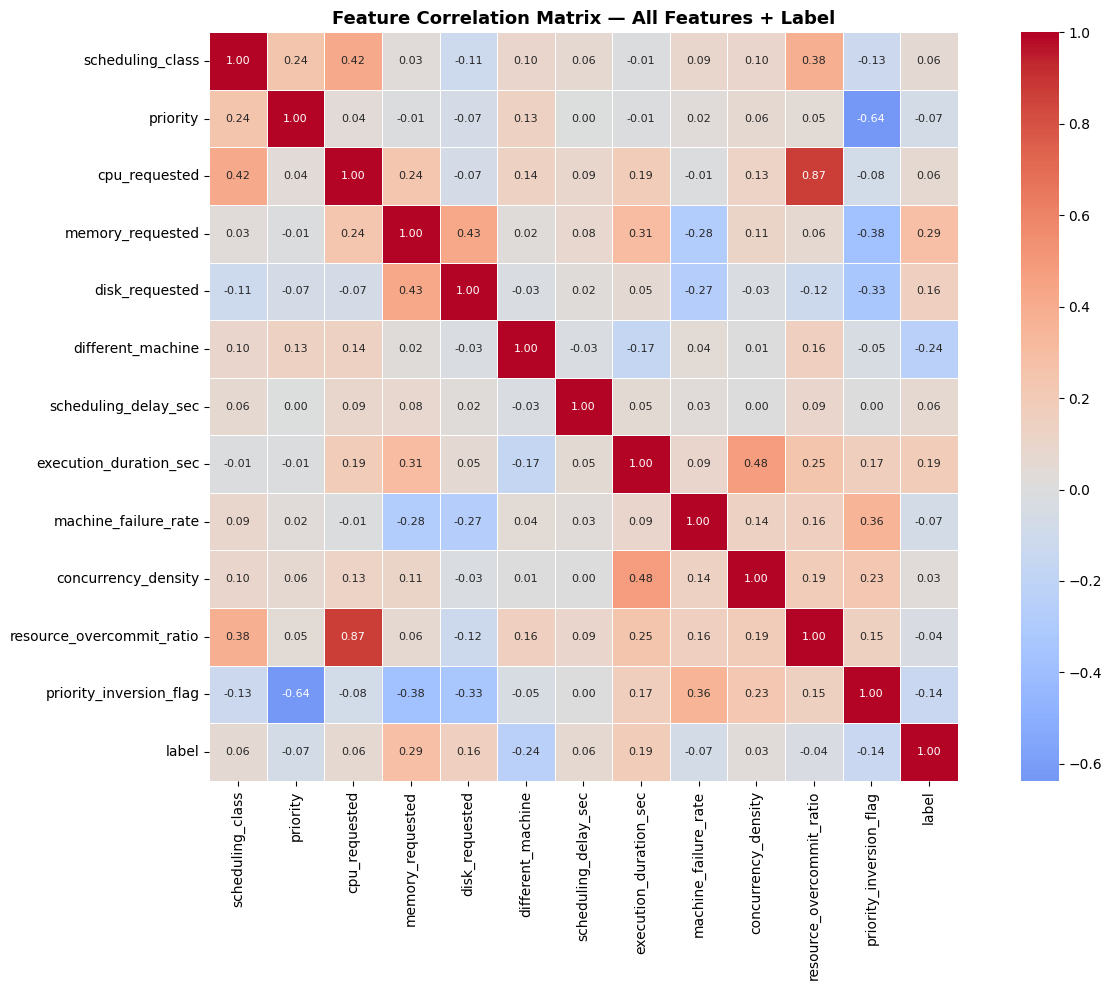

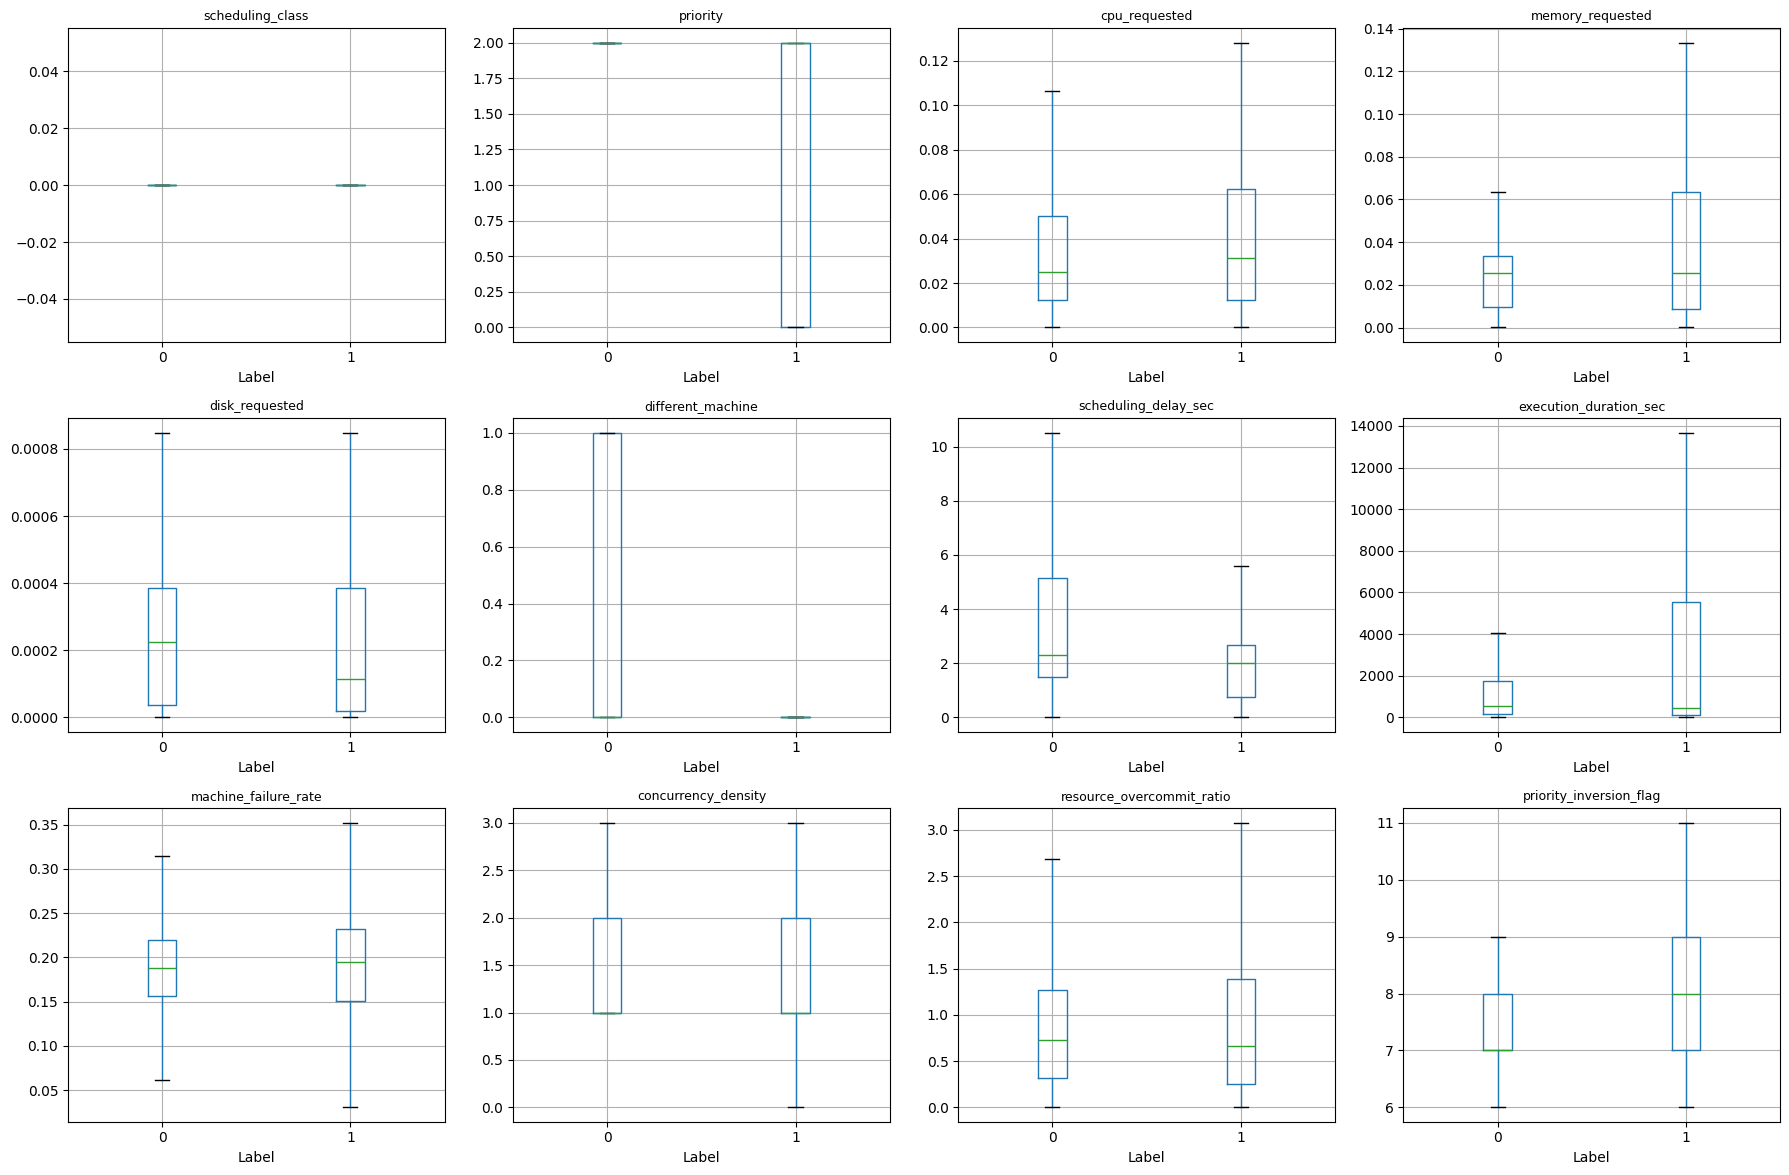


Saved: feature_matrix.csv
Shape: (300644, 16)

 SUMMARY 
Input rows (clean)       : 1,827,856
Input rows (labelled)    : 300,644
Raw features             : 6
Novel engineered features: 6
Total features           : 12
Output shape             : (300644, 16)
Nulls remaining          : 0

Feature                    Corr with Label
---------------------------------------------
  memory_requested               +0.2869
  different_machine              -0.2357
  execution_duration_sec         +0.1932
  disk_requested                 +0.1581
  priority_inversion_flag        -0.1430
  priority                       -0.0726
  machine_failure_rate           -0.0719
  cpu_requested                  +0.0618
  scheduling_delay_sec           +0.0614
  scheduling_class               +0.0599
  resource_overcommit_ratio      -0.0358
  concurrency_density            +0.0314


In [14]:
ALL_FEATURES = [
    'scheduling_class',
    'priority',
    'cpu_requested',
    'memory_requested',
    'disk_requested',
    'different_machine',
    'scheduling_delay_sec',
    'execution_duration_sec',
    'machine_failure_rate',
    'concurrency_density',
    'resource_overcommit_ratio',
    'priority_inversion_flag'
]

print("=" * 55)
print(" FEATURE SUMMARY STATISTICS")
print("=" * 55)
print(feature_matrix[ALL_FEATURES].describe().round(4))

# Correlation with label 
print("\n" + "=" * 55)
print(" CORRELATION OF EACH FEATURE WITH LABEL")
print("=" * 55)
corr_with_label = (feature_matrix[ALL_FEATURES + ['label']]
                   .corr()['label']
                   .drop('label')
                   .sort_values(ascending=False, key=abs))
print(corr_with_label.round(4))

# Full correlation heatmap 
plt.figure(figsize=(14, 10))
corr_matrix = feature_matrix[ALL_FEATURES + ['label']].corr()
sns.heatmap(
    corr_matrix,
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    center=0,
    square=True,
    linewidths=0.5,
    annot_kws={'size': 8}
)
plt.title('Feature Correlation Matrix — All Features + Label',
          fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('feature_correlation.png', dpi=150)
plt.show()

# ── Feature distribution by label ────────────────────────────
fig, axes = plt.subplots(3, 4, figsize=(18, 12))
fig.suptitle('All Features Distribution by Label',
             fontsize=13, fontweight='bold')
axes = axes.flatten()

for i, feat in enumerate(ALL_FEATURES):
    feature_matrix.boxplot(
        column=feat,
        by='label',
        ax=axes[i],
        showfliers=False
    )
    axes[i].set_title(feat, fontsize=9)
    axes[i].set_xlabel('Label')
    axes[i].set_ylabel('')

plt.suptitle('')
plt.tight_layout()
plt.savefig('all_features_by_label.png', dpi=150)
plt.show()

# Save feature matrix 
feature_matrix.to_csv('/kaggle/working/feature_matrix.csv', index=False)
print("\nSaved: feature_matrix.csv")
print(f"Shape: {feature_matrix.shape}")

print("\n" + "=" * 55)
print(" SUMMARY ")
print("=" * 55)
print(f"Input rows (clean)       : {len(df_clean):,}")
print(f"Input rows (labelled)    : {len(df_label):,}")
print(f"Raw features             : 6")
print(f"Novel engineered features: 6")
print(f"Total features           : 12")
print(f"Output shape             : {feature_matrix.shape}")
print(f"Nulls remaining          : 0")
print(f"\nFeature                    Corr with Label")
print("-" * 45)
for feat, val in corr_with_label.items():
    print(f"  {feat:<30} {val:>+.4f}")
